# Signal Sampling & The Nyquist–Shannon Theorem

Sampling converts a continuous-time signal $x(t)$ into a discrete sequence by reading its amplitude at regular time intervals $T_s = 1/f_s$:

$$x_s(t) = x(t) \cdot \sum_{n=-\infty}^{+\infty} \delta(t - nT_s) \quad\Longrightarrow\quad x[n] = x(nT_s)$$

The **sampling rate** $f_s$ (Hz) is the number of samples collected per second. The **Nyquist frequency** $f_N = f_s/2$ marks the highest frequency that can be faithfully represented. Use the interactive sliders in each section to observe — directly — what happens in both time and frequency as $f_s$ changes.

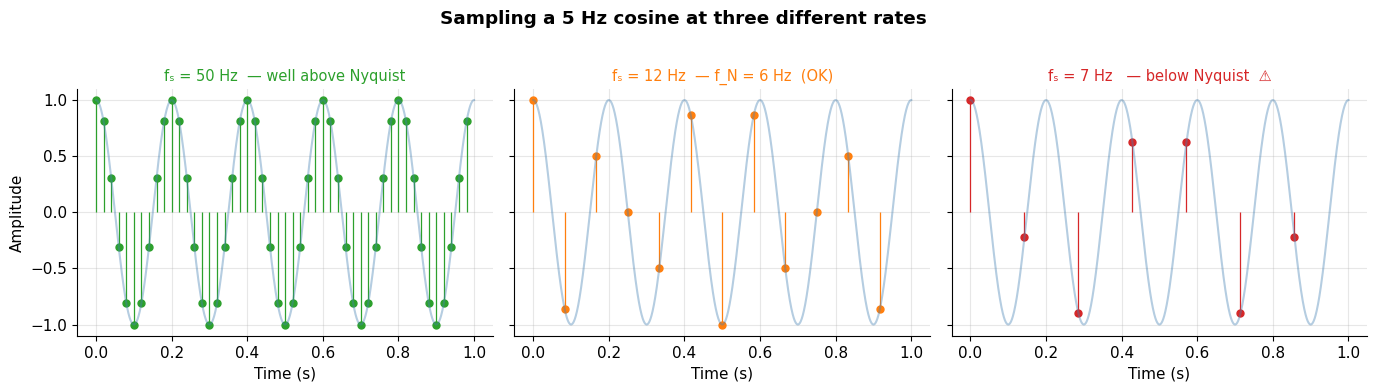

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from matplotlib.lines import Line2D
%matplotlib inline

plt.rcParams.update({
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3,
    'figure.dpi': 100, 'font.size': 11,
    'axes.labelsize': 11, 'axes.titlesize': 12,
})

f0_demo, dur = 5, 1.0
t_c = np.linspace(0, dur, 2000)
x_c = np.cos(2 * np.pi * f0_demo * t_c)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), sharey=True)
configs = [
    (50, 'fₛ = 50 Hz  — well above Nyquist',  '#2ca02c'),
    (12, 'fₛ = 12 Hz  — f_N = 6 Hz  (OK)',    '#ff7f0e'),
    ( 7, 'fₛ = 7 Hz   — below Nyquist  ⚠',    '#d62728'),
]

for ax, (fs, label, color) in zip(axes, configs):
    t_s = np.arange(0, dur, 1 / fs)
    mk, st, _ = ax.stem(t_s, np.cos(2 * np.pi * f0_demo * t_s),
                        linefmt='-', markerfmt='o', basefmt=' ')
    plt.setp(st, color=color, lw=0.9)
    plt.setp(mk, color=color, ms=5)
    ax.plot(t_c, x_c, 'steelblue', lw=1.5, alpha=0.4)
    ax.set_title(label, color=color, fontsize=10.5)
    ax.set_xlabel('Time (s)')

axes[0].set_ylabel('Amplitude')
fig.suptitle(f'Sampling a {f0_demo} Hz cosine at three different rates',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Time-Domain View of Sampling

After sampling, the only information available is the set of values $\{x[n]\}$. **Ideal reconstruction** back to continuous time applies a perfect low-pass filter, equivalent to the *sinc interpolation* formula:

$$\hat{x}(t) = \sum_{n} x[n]\,\operatorname{sinc}\!\left(\frac{t - nT_s}{T_s}\right), \qquad \operatorname{sinc}(u) = \frac{\sin(\pi u)}{\pi u}$$

When $f_s > 2f_0$, the reconstructed signal is identical to the original. When $f_s < 2f_0$, reconstruction produces the **alias** — a different frequency that happens to pass through the same sample points.

> Suggestion: start with $f_0 = 4$ Hz and $f_s = 22$ Hz (OK), then slowly reduce $f_s$ past $8$ Hz to watch the alias appear.

In [ ]:
def build_time_demo():
    sl = dict(style={'description_width': '128px'}, layout=widgets.Layout(width='390px'))
    f0_w = widgets.FloatSlider(value=4, min=1, max=20, step=0.5,
                               description='f₀  signal (Hz)', **sl)
    fs_w = widgets.FloatSlider(value=22, min=3, max=80, step=1,
                               description='fₛ  sampling (Hz)', **sl)
    out = widgets.Output()

    def update(_):
        f0, fs   = f0_w.value, fs_w.value
        Ts, nyq  = 1 / fs, fs / 2
        aliased  = f0 > nyq
        color    = '#d62728' if aliased else '#2ca02c'
        status   = (f'⚠  ALIASING  — f₀ ({f0:.1f} Hz) > fₙ ({nyq:.0f} Hz)'
                    if aliased else
                    f'✓  OK  — f₀ ({f0:.1f} Hz) ≤ fₙ ({nyq:.0f} Hz)')

        dur  = 2.0
        t_c  = np.linspace(0, dur, 4000)
        x_c  = np.cos(2 * np.pi * f0 * t_c)
        t_s  = np.arange(0, dur + Ts / 10, Ts)
        t_s  = t_s[t_s <= dur]
        x_s  = np.cos(2 * np.pi * f0 * t_s)

        # Vectorized sinc interpolation:  (M,) @ (M, N)  →  (N,)
        x_rec = x_s @ np.sinc((t_c[np.newaxis, :] - t_s[:, np.newaxis]) / Ts)

        with out:
            clear_output(wait=True)
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.3))

            ax1.plot(t_c, x_c, 'steelblue', lw=1.5, alpha=0.4)
            mk, st, _ = ax1.stem(t_s, x_s, linefmt='C1-', markerfmt='C1o', basefmt=' ')
            plt.setp(st, lw=0.9, alpha=0.85); plt.setp(mk, ms=5)
            ax1.set_xlabel('Time (s)'); ax1.set_ylabel('Amplitude')
            ax1.set_title(f'Sampling  |  f₀={f0:.1f} Hz,  fₛ={fs:.0f} Hz,  {len(t_s)} samples')
            ax1.legend(handles=[
                Line2D([0],[0], color='steelblue', lw=1.5, alpha=0.5, label='$x(t)$ continuous'),
                Line2D([0],[0], color='C1', marker='o', ms=5, lw=0.9, label=f'Samples ({len(t_s)})')
            ], fontsize=9)
            ax1.set_ylim(-1.6, 1.6)

            ax2.plot(t_c, x_c, 'steelblue', lw=1.5, alpha=0.3, label='Original')
            ax2.plot(t_c, x_rec, color=color, lw=2, label='Reconstructed (sinc)')
            mk2, st2, _ = ax2.stem(t_s, x_s, linefmt='gray', markerfmt='ko', basefmt=' ')
            plt.setp(st2, lw=0.5, alpha=0.4); plt.setp(mk2, ms=3.5, alpha=0.6)
            ax2.set_xlabel('Time (s)')
            ax2.set_title(f'Reconstruction  |  {status}', color=color, fontsize=10.5)
            ax2.legend(fontsize=9); ax2.set_ylim(-1.6, 1.6)

            plt.tight_layout(); plt.show()

    for w in (f0_w, fs_w):
        w.observe(update, names='value')
    display(widgets.VBox([widgets.HBox([f0_w, fs_w]), out]))
    update(None)

build_time_demo()

## Frequency-Domain Effects of Sampling

Multiplication by the impulse train in time corresponds to **convolution** with a frequency-domain impulse train. This replicates the original spectrum $X(f)$ periodically at every integer multiple of $f_s$:

$$X_s(f) = f_s \sum_{k=-\infty}^{+\infty} X(f - k f_s)$$

For a tone at $f_0$, the sampled spectrum contains lines at $\pm f_0 + k f_s$ for all integers $k$. The **DFT** of the sampled sequence folds these replicas into the observable range $[0,\, f_s/2]$.

When $f_s \geq 2 f_0$, replicas are separated and $X(f)$ is recoverable with an ideal low-pass filter of cutoff $f_s/2$.  
When $f_s < 2 f_0$, replicas **overlap** — the original and its images collide, and the information is irrecoverably lost.

> Suggestion: set $f_0 = 12$ Hz, then decrease $f_s$ from $60$ down to $15$ Hz to watch replicas collide.

In [14]:
def build_freq_demo():
    sl = dict(style={'description_width': '128px'}, layout=widgets.Layout(width='390px'))
    f0_w = widgets.FloatSlider(value=4, min=1, max=25, step=0.5,
                               description='f₀  signal (Hz)', **sl)
    fs_w = widgets.FloatSlider(value=30, min=5, max=100, step=5,
                               description='fₛ  sampling (Hz)', **sl)
    out = widgets.Output()

    def draw_line(ax, f, h, c, lw=2, alpha=1.0):
        ax.plot([f, f], [0, h], color=c, lw=lw, alpha=alpha)
        ax.plot(f, h, marker='^', color=c, ms=7, alpha=alpha)

    def update(_):
        f0, fs  = f0_w.value, fs_w.value
        nyq     = fs / 2
        aliased = f0 > nyq
        f_alias = abs(((f0 + nyq) % fs) - nyq)
        color   = '#d62728' if aliased else '#2ca02c'

        dur  = 6.0
        t_s  = np.arange(0, dur, 1 / fs)
        x_s  = np.cos(2 * np.pi * f0 * t_s)
        N    = len(t_s)
        Nfft = max(N * 16, 8192)
        X_mag = 2 * np.abs(np.fft.rfft(x_s, n=Nfft)) / N
        freqs = np.fft.rfftfreq(Nfft, d=1 / fs)

        f_plot = min(max(3.0 * f0, 2.5 * fs), 150)

        with out:
            clear_output(wait=True)
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.8))

            # Left panel — conceptual spectral replicas
            for sign in [1, -1]:
                draw_line(ax1, sign * f0, 1.0, 'steelblue', lw=2.5)
            for k in [-3, -2, -1, 1, 2, 3]:
                alpha_k = max(0.2, 0.85 - 0.14 * abs(k))
                for sign in [1, -1]:
                    fr = sign * f0 + k * fs
                    if -f_plot <= fr <= f_plot:
                        draw_line(ax1, fr, 0.85, 'darkorange', lw=1.8, alpha=alpha_k)
            if aliased:
                draw_line(ax1,  f_alias, 1.15, color, lw=3)
                draw_line(ax1, -f_alias, 1.15, color, lw=3)
                ax1.text(f_alias, 1.26, f'fₐₗ = {f_alias:.1f} Hz',
                         ha='center', color=color, fontsize=9, fontweight='bold')

            ax1.axvline( nyq, color='#2ca02c', ls='--', lw=1.8, alpha=0.85)
            ax1.axvline(-nyq, color='#2ca02c', ls='--', lw=1.8, alpha=0.85)
            ax1.axhline(0, color='black', lw=0.8)
            ax1.set_xlim(-f_plot, f_plot); ax1.set_ylim(-0.08, 1.45)
            ax1.set_xlabel('Frequency (Hz)'); ax1.set_ylabel('|X_s(f)| (normalized)')
            ax1.set_title('Spectral Replicas' + (' — ⚠ OVERLAP' if aliased else ' — ✓ Separated'),
                          color=color)
            leg1 = [
                Line2D([0],[0], color='steelblue', lw=2.5, label=f'±f₀ = ±{f0:.1f} Hz'),
                Line2D([0],[0], color='darkorange', lw=1.8, label='Replicas  ±f₀ + k·fₛ'),
                Line2D([0],[0], color='#2ca02c', ls='--', lw=1.8, label=f'Nyquist  ±{nyq:.0f} Hz'),
            ]
            if aliased:
                leg1.append(Line2D([0],[0], color=color, lw=3,
                                   label=f'Alias  ±{f_alias:.1f} Hz'))
            ax1.legend(handles=leg1, fontsize=8.5, loc='upper right')

            # Right panel — computed DFT magnitude
            mask = freqs <= freqs[-1]
            ax2.fill_between(freqs[mask], X_mag[mask], alpha=0.25, color='steelblue')
            ax2.plot(freqs[mask], X_mag[mask], color='steelblue', lw=1.5, label='DFT magnitude')
            ax2.axvline(nyq, color='#2ca02c', ls='--', lw=1.8, label=f'Nyquist = {nyq:.0f} Hz')
            ax2.axvline(f0,  color='steelblue', ls=':', lw=1.5, alpha=0.55,
                        label=f'True f₀ = {f0:.1f} Hz')
            if aliased:
                ax2.axvline(f_alias, color=color, lw=2.5,
                            label=f'Alias peak = {f_alias:.1f} Hz')
                ax2.set_title(f'DFT  — ⚠ Alias at {f_alias:.1f} Hz', color=color)
            else:
                ax2.set_title(f'DFT  — ✓ f₀ resolved correctly', color=color)
            ax2.set_xlabel('Frequency (Hz)'); ax2.set_ylabel('Magnitude (normalized)')
            ax2.set_xlim(0, freqs[-1] * 1.02)
            ax2.legend(fontsize=8.5)

            plt.tight_layout(); plt.show()

    for w in (f0_w, fs_w):
        w.observe(update, names='value')
    display(widgets.VBox([widgets.HBox([f0_w, fs_w]), out]))
    update(None)

build_freq_demo()

## The Nyquist–Shannon Sampling Theorem

> **A band-limited signal with maximum frequency $f_{\max}$ can be perfectly recovered from its samples if and only if $f_s > 2\,f_{\max}$.**

The threshold $2 f_{\max}$ is the **Nyquist rate**. The factor of 2 follows directly from the replica spacing: replicas in $X_s(f)$ are centered at integer multiples of $f_s$, so they remain non-overlapping only if each spans at most $f_s/2$.

| Condition | Time domain | Frequency domain |
|:---|:---|:---|
| $f_s > 2 f_{\max}$ | Sinc reconstruction is exact | Replicas fully separated |
| $f_s = 2 f_{\max}$ | Marginal — phase-sensitive | Replicas just touch at $\pm f_s/2$ |
| $f_s < 2 f_{\max}$ | Alias appears at wrong frequency | Replicas overlap; information lost |

The **alias frequency** for a tone $f_0$ sampled at $f_s$ is:

$$f_{\text{alias}} = \left|\left(\bigl(f_0 + \tfrac{f_s}{2}\bigr) \bmod f_s\right) - \tfrac{f_s}{2}\right|$$

**Key insight:** aliasing is *irreversible*. A 3 Hz tone sampled at 10 Hz and a 7 Hz tone sampled at 10 Hz produce identical sample sequences — no algorithm can distinguish them after the fact.

In [4]:
def build_combined_demo():
    sl = dict(style={'description_width': '140px'}, layout=widgets.Layout(width='420px'))
    f0_w = widgets.FloatSlider(value=4, min=0.5, max=25, step=0.5,
                               description='f₀  signal (Hz)', **sl)
    fs_w = widgets.FloatSlider(value=20, min=3, max=100, step=1,
                               description='fₛ  sampling (Hz)', **sl)
    status_w = widgets.HTML()
    out = widgets.Output()

    def draw_line(ax, f, h, c, lw=2, alpha=1.0):
        ax.plot([f, f], [0, h], color=c, lw=lw, alpha=alpha)
        ax.plot(f, h, marker='^', color=c, ms=7, alpha=alpha)

    def update(_):
        f0, fs   = f0_w.value, fs_w.value
        Ts, nyq  = 1 / fs, fs / 2
        aliased  = f0 > nyq
        f_alias  = abs(((f0 + nyq) % fs) - nyq)
        color    = '#d62728' if aliased else '#2ca02c'
        bg_color = '#fff3f3' if aliased else '#f3fff5'

        if aliased:
            msg = (f'⚠&nbsp; ALIASING — f₀ ({f0:.1f} Hz) &gt; f_N ({nyq:.0f} Hz)'
                   f'&nbsp;&nbsp;|&nbsp;&nbsp;alias at <b>{f_alias:.1f} Hz</b>')
        else:
            msg = f'✓&nbsp; Nyquist satisfied — f₀ ({f0:.1f} Hz) ≤ f_N ({nyq:.0f} Hz)'
        status_w.value = (
            f'<div style="padding:7px 14px; border-radius:6px; '
            f'background:{bg_color}; color:{color}; '
            f'font-size:14px; font-weight:bold; margin-bottom:6px">{msg}</div>'
        )

        dur  = 2.0
        t_c  = np.linspace(0, dur, 4000)
        x_c  = np.cos(2 * np.pi * f0 * t_c)
        t_s  = np.arange(0, dur + Ts / 10, Ts)
        t_s  = t_s[t_s <= dur]
        x_s  = np.cos(2 * np.pi * f0 * t_s)

        # Vectorized sinc interpolation
        x_rec = x_s @ np.sinc((t_c[np.newaxis, :] - t_s[:, np.newaxis]) / Ts)

        N    = len(t_s)
        Nfft = max(N * 16, 8192)
        X_mag = 2 * np.abs(np.fft.rfft(x_s, n=Nfft)) / N
        freqs = np.fft.rfftfreq(Nfft, d=Ts)

        f_plot = min(max(3.0 * f0, 2.5 * fs), 150)

        with out:
            clear_output(wait=True)
            fig = plt.figure(figsize=(14, 9))
            gs = fig.add_gridspec(2, 2, hspace=0.46, wspace=0.32)
            ax1 = fig.add_subplot(gs[0, 0])
            ax2 = fig.add_subplot(gs[0, 1])
            ax3 = fig.add_subplot(gs[1, 0])
            ax4 = fig.add_subplot(gs[1, 1])

            # Top-left: sampling in time
            ax1.plot(t_c, x_c, 'steelblue', lw=1.5, alpha=0.4)
            mk, st, _ = ax1.stem(t_s, x_s, linefmt='C1-', markerfmt='C1o', basefmt=' ')
            plt.setp(st, lw=0.9, alpha=0.85); plt.setp(mk, ms=4.5)
            ax1.set_xlabel('Time (s)'); ax1.set_ylabel('Amplitude')
            ax1.set_title(f'Sampling  ({len(t_s)} samples,  fₛ={fs:.0f} Hz)')
            ax1.legend(handles=[
                Line2D([0],[0], color='steelblue', lw=1.5, alpha=0.5, label='$x(t)$'),
                Line2D([0],[0], color='C1', marker='o', ms=5, lw=0.9, label='Samples')
            ], fontsize=9)
            ax1.set_ylim(-1.6, 1.6)

            # Top-right: DFT magnitude
            mask = freqs <= freqs[-1]
            ax2.fill_between(freqs[mask], X_mag[mask], alpha=0.25, color='steelblue')
            ax2.plot(freqs[mask], X_mag[mask], 'steelblue', lw=1.5)
            ax2.axvline(nyq, color='#2ca02c', ls='--', lw=1.8, label=f'Nyquist = {nyq:.0f} Hz')
            ax2.axvline(f0,  color='steelblue', ls=':', lw=1.5, alpha=0.55,
                        label=f'f₀ = {f0:.1f} Hz')
            if aliased:
                ax2.axvline(f_alias, color=color, lw=2.5, label=f'Alias = {f_alias:.1f} Hz')
            ax2.set_title('DFT Magnitude Spectrum', color=color)
            ax2.set_xlabel('Frequency (Hz)'); ax2.set_ylabel('|X[k]| (normalized)')
            ax2.legend(fontsize=9); ax2.set_xlim(0, freqs[-1] * 1.02)

            # Bottom-left: sinc reconstruction
            ax3.plot(t_c, x_c, 'steelblue', lw=1.5, alpha=0.3, label='Original')
            ax3.plot(t_c, x_rec, color=color, lw=2, label='Reconstructed (sinc)')
            mk3, st3, _ = ax3.stem(t_s, x_s, linefmt='gray', markerfmt='ko', basefmt=' ')
            plt.setp(st3, lw=0.5, alpha=0.35); plt.setp(mk3, ms=3.5, alpha=0.5)
            ax3.set_xlabel('Time (s)'); ax3.set_ylabel('Amplitude')
            ax3.set_title('Sinc Interpolation Reconstruction')
            ax3.legend(fontsize=9); ax3.set_ylim(-1.6, 1.6)

            # Bottom-right: conceptual spectral replicas
            for sign in [1, -1]:
                draw_line(ax4, sign * f0, 1.0, 'steelblue', lw=2.5)
            for k in [-3, -2, -1, 1, 2, 3]:
                alpha_k = max(0.2, 0.85 - 0.14 * abs(k))
                for sign in [1, -1]:
                    fr = sign * f0 + k * fs
                    if -f_plot <= fr <= f_plot:
                        draw_line(ax4, fr, 0.85, 'darkorange', lw=1.8, alpha=alpha_k)
            if aliased:
                draw_line(ax4,  f_alias, 1.15, color, lw=3)
                draw_line(ax4, -f_alias, 1.15, color, lw=3)
                ax4.text(f_alias, 1.26, f'fₐₗ = {f_alias:.1f} Hz',
                         ha='center', color=color, fontsize=9, fontweight='bold')
            ax4.axvline( nyq, color='#2ca02c', ls='--', lw=1.8, alpha=0.85)
            ax4.axvline(-nyq, color='#2ca02c', ls='--', lw=1.8, alpha=0.85)
            ax4.axhline(0, color='black', lw=0.8)
            ax4.set_xlim(-f_plot, f_plot); ax4.set_ylim(-0.08, 1.45)
            ax4.set_xlabel('Frequency (Hz)'); ax4.set_ylabel('|X_s(f)|')
            ax4.set_title('Spectral Replicas (conceptual)', color=color)
            leg4 = [
                Line2D([0],[0], color='steelblue', lw=2.5, label=f'±f₀ = ±{f0:.1f} Hz'),
                Line2D([0],[0], color='darkorange', lw=1.8, label='Replicas  ±f₀ + k·fₛ'),
                Line2D([0],[0], color='#2ca02c', ls='--', lw=1.8, label=f'Nyquist  ±{nyq:.0f} Hz'),
            ]
            if aliased:
                leg4.append(Line2D([0],[0], color=color, lw=3,
                                   label=f'Alias  ±{f_alias:.1f} Hz'))
            ax4.legend(handles=leg4, fontsize=8.5, loc='upper right')

            plt.show()

    for w in (f0_w, fs_w):
        w.observe(update, names='value')
    display(widgets.VBox([status_w, widgets.HBox([f0_w, fs_w]), out]))
    update(None)

build_combined_demo()